In [1]:
!git clone https://github.com/mpalesi/qcomm.git

Cloning into 'qcomm'...
remote: Enumerating objects: 523, done.
remote: Counting objects: 100% (374/374), done.
remote: Compressing objects: 100% (268/268), done.
remote: Total 523 (delta 268), reused 202 (delta 105), pack-reused 149 (from 1)
Receiving objects: 100% (523/523), 127.41 KiB | 4.55 MiB/s, done.
Resolving deltas: 100% (357/357), done.


In [2]:
%cd qcomm

/content/qcomm


In [3]:
!ls

architecture.cpp   core.h	noc.h		statistics.cpp
architecture.h	   gate.cpp	parameters.cpp	statistics.h
circuit.cpp	   gate.h	parameters.h	teleportation_time.cpp
circuit.h	   LICENSE	qasm2qcomm.py	teleportation_time.h
command_line.cpp   main.cpp	rcg.cpp		utils.cpp
command_line.h	   Makefile	README.md	utils.h
communication.cpp  mapping.cpp	samples
communication.h    mapping.h	simulation.cpp
core.cpp	   noc.cpp	simulation.h


In [4]:
!make

g++ -std=c++11 -Wall -Wextra -I/opt/homebrew/opt/yaml-cpp/include -MMD -MP -c main.cpp -o obj/main.o
In file included from main.cpp:11:
utils.h:17:10: fatal error: yaml-cpp/yaml.h: No such file or directory
   17 | #include <yaml-cpp/yaml.h>
      |          ^~~~~~~~~~~~~~~~~
compilation terminated.
make: *** [Makefile:34: obj/main.o] Error 1


In [6]:
!apt-get update -qq
!apt-get install -y libyaml-cpp-dev

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libyaml-cpp0.7
The following NEW packages will be installed:
  libyaml-cpp-dev libyaml-cpp0.7
0 upgraded, 2 newly installed, 0 to remove and 73 not upgraded.
Need to get 267 kB of archives.
After this operation, 1,390 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libyaml-cpp0.7 amd64 0.7.0+dfsg-8build1 [97.7 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libyaml-cpp-dev amd64 0.7.0+dfsg-8build1 [169 kB]
Fetched 267 kB in 1s (384 kB/s)
Selecting previously unselected package libyaml-cpp0.7:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack 

In [7]:
!ls /usr/include/yaml-cpp/yaml.h

/usr/include/yaml-cpp/yaml.h


In [10]:
!sed -i 's|/opt/homebrew/opt/yaml-cpp|/usr|g' Makefile

In [11]:
!grep -n "YAML_CPP_PREFIX" Makefile

8:YAML_CPP_PREFIX := /usr
27:	$(CXX) $(CXXFLAGS) $^ -o $@ -L$(YAML_CPP_PREFIX)/lib -lyaml-cpp
30:	$(CXX) $(CXXFLAGS) $^ -o $@ -L$(YAML_CPP_PREFIX)/lib -lyaml-cpp
34:	$(CXX) $(CXXFLAGS) -I$(YAML_CPP_PREFIX)/include -MMD -MP -c $< -o $@


In [12]:
!make

g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c main.cpp -o obj/main.o
g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c architecture.cpp -o obj/architecture.o
g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c noc.cpp -o obj/noc.o
g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c circuit.cpp -o obj/circuit.o
g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c communication.cpp -o obj/communication.o
g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c teleportation_time.cpp -o obj/teleportation_time.o
g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c core.cpp -o obj/core.o
g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c gate.cpp -o obj/gate.o
g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c mapping.cpp -o obj/mapping.o
g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c parameters.cpp -o obj/parameters.o
g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c statistics.cpp -o obj/statistics.o
g++ -std=c++11 -Wall -Wextra -I/usr

In [13]:
!ls -lh qcomm rcg

-rwxr-xr-x 1 root root 758K Sep  2 13:35 qcomm
-rwxr-xr-x 1 root root 253K Sep  2 13:35 rcg


In [14]:
!cat samples/architecture.yaml

mesh_x: 2
mesh_y: 2
link_width: 8
qubits_per_core: 10
ltm_ports: 1
radio_channels: 1
wireless_enabled: false
wireless_mac: 0 # 0=token-based, 1=instruction-directed
teleportation_type: 0 # 0=all-to-all, 1=mesh
dst_selection_mode: 1 # 0=load-independent, 1=load-aware
mapping_type: 1 # 0=random, 1=sequential


In [15]:
!cat samples/circuit

G2(2 5) G1(4) 
G2(0 2) G2(5 6) G2(1 4) 
G2(2 6) G1(1) G2(5 7) 
G2(4 7) 
G1(6) G2(2 3) 
G1(7) 
G1(3) G1(1) 
G2(4 7) 


1 port

In [16]:
!./qcomm \
  -c samples/circuit \
  -a samples/architecture.yaml \
  -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 15
  number_of_stages: 8
  distribution_of_gates:
    '1-input': 40 # %
    '2-input': 60 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      

2 ports

In [17]:
!./qcomm \
  -c samples/circuit \
  -a samples/architecture.yaml \
  -p samples/parameters.yaml \
  -o ltm_ports 2


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/circuit -a samples/architecture.yaml -p samples/parameters.yaml -o ltm_ports 2'

Circuit:
  number_of_qubits: 8
  number_of_gates: 15
  number_of_stages: 8
  distribution_of_gates:
    '1-input': 40 # %
    '2-input': 60 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 2
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_p

3 ports

In [18]:
!./qcomm \
  -c samples/circuit \
  -a samples/architecture.yaml \
  -p samples/parameters.yaml \
  -o ltm_ports 3


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/circuit -a samples/architecture.yaml -p samples/parameters.yaml -o ltm_ports 3'

Circuit:
  number_of_qubits: 8
  number_of_gates: 15
  number_of_stages: 8
  distribution_of_gates:
    '1-input': 40 # %
    '2-input': 60 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_p

4 ports

In [19]:
!./qcomm \
  -c samples/circuit \
  -a samples/architecture.yaml \
  -p samples/parameters.yaml \
  -o ltm_ports 4


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/circuit -a samples/architecture.yaml -p samples/parameters.yaml -o ltm_ports 4'

Circuit:
  number_of_qubits: 8
  number_of_gates: 15
  number_of_stages: 8
  distribution_of_gates:
    '1-input': 40 # %
    '2-input': 60 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 4
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_p

5 ports

In [20]:
!./qcomm \
  -c samples/circuit \
  -a samples/architecture.yaml \
  -p samples/parameters.yaml \
  -o ltm_ports 5


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/circuit -a samples/architecture.yaml -p samples/parameters.yaml -o ltm_ports 5'

Circuit:
  number_of_qubits: 8
  number_of_gates: 15
  number_of_stages: 8
  distribution_of_gates:
    '1-input': 40 # %
    '2-input': 60 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 5
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_p

In [22]:
!./rcg -h

Use ./rcg <nqubits> <ngates> <prob1 prob2 ... prob_n>
rcg: rcg.cpp:52: int main(int, char**): Assertion `false' failed.


In [23]:
!sed -n '1,180p' rcg.cpp

// =============================================================================
// Project: qcomm - Quantum Communication Simulator
// File: rcg.cpp
// Description: Standalone tool for random circuit generation
// Author: Maurizio Palesi <maurizio.palesi@unict.it>
// License: Apache-2.0 license (see LICENSE file for details)
// =============================================================================


#include <iostream>
#include <vector>
#include <cassert>
#include "gate.h"
#include "circuit.h"

using namespace std;


bool checkCommandLine(int argc, char* argv[],
		      int& nqubits, int& ngates, vector<float>& prob)
{
  if (argc < 4)
    return false;

  nqubits = atoi(argv[1]);
  ngates = atoi(argv[2]);
  prob.clear();
  for (int i=3; i<argc; i++)
    prob.push_back(atof(argv[i]));
  
  return true;
}

bool checkProbabilities(const vector<float>& vprob)
{
  float sum = 0.0;

  for (const auto& prob : vprob)
    sum += prob;

  return (sum == 1.0);
}

int main(int argc, char* 

In [25]:
!grep -n -A120 -B10 "generateCircuit" circuit.cpp

107-    std::cerr << "Qubit indices must start from 0" << std::endl;
108-    return false;
109-  }
110-
111-  number_of_qubits = max_qubit - min_qubit + 1;
112-
113-  return true;
114-}
115-
116-
117:void Circuit::generateCircuit(const int nqubits, const int ngates,
118-			      const vector<float>& gateprob)
119-{
120-  circuit.clear();
121-  int gatecount = 0;
122-  int nstages = 0;
123-  set<int> used_qubits;
124-  ParallelGates parallel_gates;
125-
126-  while (gatecount != ngates)
127-    {
128-      int fanin = getRandomNumber(gateprob) + 1;
129-      set<int> qubits = getRandomNoRepetition(nqubits, fanin);
130-
131-      set<int> intersection_set;	
132-      set_intersection(used_qubits.begin(), used_qubits.end(),
133-		       qubits.begin(), qubits.end(),
134-		       inserter(intersection_set, intersection_set.begin()));
135-
136-      if (intersection_set.empty())
137-	{
138-	  // add the gate into the parallel_gates set
139-	  Gate gate;
140-	  // the name of the gate is Gn 

In [26]:
!grep -n -A120 -B20 "parallel_communications" simulation.cpp

152-  for (const auto& qb : gate.second)
153-    {
154-      int src_core = mapping.qubit2core[qb];
155-
156-      if (src_core != dst_core)
157-	{
158-	  mapping.qubit2core[qb] = dst_core;
159-	  cores.cores[dst_core].insert(qb);
160-	  assert((int)cores.cores[dst_core].size() < architecture.qubits_per_core);
161-	  
162-	  auto it = cores.cores[src_core].find(qb);
163-	  assert(it != cores.cores[src_core].end());
164-	  cores.cores[src_core].erase(it);
165-	}
166-    }
167-}
168-
169-// ----------------------------------------------------------------------
170-// Generate communications from the core where the qubits of gate are
171-// mapped onto to the dst_core and insert them into
172:// parallel_communications
173:void Simulation::addParallelCommunications(ParallelCommunications& parallel_communications,
174-					   const Gate& gate, const int dst_core,
175-					   const Mapping& mapping,
176-					   const int volume)
177-{
178-  for (const auto& qb : gate.second)
179-    {
180- 

In [27]:
!grep -n -A100 -B20 "remoteExecution" simulation.cpp

229-  TeleportationTime tp_time = getTeleportationTime(pcomms, noc, params);
230-  				       
231-  addTeleportationTime(stats.teleportation_time, tp_time);
232-
233-  stats.addIntercoreCommunications(pcomms);
234-  
235-  stats.computation_time += getMaxGateLatency(pgates, params.gate_delays);
236-}
237-
238-// ----------------------------------------------------------------------
239-void Simulation::removeExecutedGates(const ParallelGates& scheduled_gates,
240-				     ParallelGates& gates)
241-{
242-  // Remove scheduled_gates from gates
243-  gates.remove_if([&scheduled_gates](const Gate &gate) {
244-    return std::find(scheduled_gates.begin(), scheduled_gates.end(), gate) != scheduled_gates.end();
245-    });
246-}
247-
248-// ----------------------------------------------------------------------
249:Statistics Simulation::remoteExecution(const Architecture& architecture, const NoC& noc,
250-				       const Parameters& parameters,
251-				       const ParallelGates& rgates,
25

In [28]:
!grep -n -A100 -B20 "selectDestinationCore" simulation.cpp

91-  if (!lgates.empty())
92-    {
93-      // lgates are executed in parallel; the latency is determined by
94-      // the slowest gate
95-      stats.computation_time = getMaxGateLatency(lgates, params.gate_delays);
96-      // TODO: add swap contribution like in the remote execution
97-      stats.executed_gates = lgates.size();
98-    }
99-
100-  stats.addOperationsPerQubit(lgates);
101-  
102-  return stats;
103-}
104-
105-// ----------------------------------------------------------------------
106-// Choose the target core based on the number of allocated
107-// qubits. Select the core with the fewest allocated qubits.  This is
108-// valid only for telepot_type all-to-all and if option TODO is set
109-// otherwise it is assumed that the first qubit is the source and the
110-// second is the destination.
111:int Simulation::selectDestinationCore(const Architecture& architecture,
112-				      const Gate& gate, const Mapping& mapping, const Cores& cores)
113-{
114-  int selected

In [29]:
!grep -n -A80 -B10 "splitLocalRemoteGates" simulation.cpp

34-  int core_id = mapping.qubit2CoreSafe(gate.second.front()); // core where the first qubit of the gate is mapped to
35-
36-  for (const auto& qb : gate.second)
37-    if (mapping.qubit2CoreSafe(qb) != core_id)
38-      return false;
39-
40-  return true;
41-}
42-
43-// ----------------------------------------------------------------------
44:void Simulation::splitLocalRemoteGates(const ParallelGates& pgates, const Mapping& mapping,
45-				       ParallelGates& lgates, ParallelGates& rgates)
46-{
47-  lgates.clear();
48-  rgates.clear();
49-  
50-  for (const auto& gate : pgates)
51-    {
52-      if (isLocalGate(gate, mapping))
53-	lgates.push_back(gate);
54-      else
55-	rgates.push_back(gate);
56-    }
57-}
58-
59-// ----------------------------------------------------------------------
60-double Simulation::getMaxGateLatency(const ParallelGates& lgates,
61-				     const map<string,double>& gate_delays)
62-{
63-  double max_delay = -1;
64-
65-  for (const auto& g : lgates)
66-  

In [30]:
!grep -n -A100 -B20 "mapping_type" architecture.cpp

23-       << IND << "total_physical_qubits: " << total_physical_qubits << endl
24-       << IND << "ltm_ports: " << ltm_ports << endl;
25-
26-  cout << IND << "teleportation_type: " << teleportation_type;
27-  if (teleportation_type == TP_TYPE_A2A)
28-    cout << " # all to all" << endl;
29-  else if (teleportation_type == TP_TYPE_MESH)
30-    cout << " # mesh" << endl;
31-  else 
32-    cout << " # ??\?" << endl;
33-
34-  cout << IND << "dst_selection_mode: " << dst_selection_mode;
35-  if (dst_selection_mode == DST_SEL_LOAD_INDEPENDENT)
36-    cout << " # load independent" << endl;
37-  else if (dst_selection_mode == DST_SEL_LOAD_AWARE)
38-    cout << " # load aware" << endl;
39-  else
40-    cout << " # ??\?" << endl;
41-  
42-  
43:  cout << IND << "mapping_type: " << mapping_type;
44:  if (mapping_type == MAP_RANDOM)
45-    cout << " # random" << endl;
46:  else if (mapping_type == MAP_SEQUENTIAL)
47-    cout << " # sequential" << endl;
48-  else
49-    cout << " # ??\?" << endl;


In [31]:
!grep -R -n -A100 -B20 "MAP_SEQUENTIAL" .

./architecture.cpp-26-  cout << IND << "teleportation_type: " << teleportation_type;
./architecture.cpp-27-  if (teleportation_type == TP_TYPE_A2A)
./architecture.cpp-28-    cout << " # all to all" << endl;
./architecture.cpp-29-  else if (teleportation_type == TP_TYPE_MESH)
./architecture.cpp-30-    cout << " # mesh" << endl;
./architecture.cpp-31-  else 
./architecture.cpp-32-    cout << " # ??\?" << endl;
./architecture.cpp-33-
./architecture.cpp-34-  cout << IND << "dst_selection_mode: " << dst_selection_mode;
./architecture.cpp-35-  if (dst_selection_mode == DST_SEL_LOAD_INDEPENDENT)
./architecture.cpp-36-    cout << " # load independent" << endl;
./architecture.cpp-37-  else if (dst_selection_mode == DST_SEL_LOAD_AWARE)
./architecture.cpp-38-    cout << " # load aware" << endl;
./architecture.cpp-39-  else
./architecture.cpp-40-    cout << " # ??\?" << endl;
./architecture.cpp-41-  
./architecture.cpp-42-  
./architecture.cpp-43-  cout << IND << "mapping_type: " << mapping_type;


In [32]:
%%writefile test1.circuit
G2(0 1)

Writing test1.circuit


In [33]:
!./qcomm -c test1.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test1.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 2
  number_of_gates: 1
  number_of_stages: 1
  distribution_of_gates:
    '2-input': 100 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      'core 0': [0]
      'cor

In [34]:
!./qcomm -c test1.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test1.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 2
  number_of_gates: 1
  number_of_stages: 1
  distribution_of_gates:
    '2-input': 100 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      'core 0': [0]
      'cor

In [36]:
!./qcomm -c test1.circuit -a samples/architecture.yaml -p samples/parameters.yaml > test1_output.txt 2>&1

/bin/bash: line 1:  5377 Segmentation fault      (core dumped) ./qcomm -c test1.circuit -a samples/architecture.yaml -p samples/parameters.yaml > test1_output.txt 2>&1


In [37]:
!cat test1_output.txt


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test1.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 2
  number_of_gates: 1
  number_of_stages: 1
  distribution_of_gates:
    '2-input': 100 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      'core 0': [0]
      'cor

In [38]:
%%writefile test1.circuit
G2(0 1)

Overwriting test1.circuit


In [39]:
!./qcomm -c test1.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test1.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 2
  number_of_gates: 1
  number_of_stages: 1
  distribution_of_gates:
    '2-input': 100 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      'core 0': [0]
      'cor

In [40]:
%%writefile test1.circuit
G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G2(0 1)

Overwriting test1.circuit


In [41]:
!./qcomm -c test1.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test1.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 9
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 88.8889 # %
    '2-input': 11.1111 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:

In [42]:
!cat test1.circuit

G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G2(0 1)


In [43]:
%%writefile test2.circuit
G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G2(0 1) G2(2 3)

Writing test2.circuit


In [44]:
!./qcomm -c test2.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test2.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 10
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      'c

In [45]:
%%writefile test3.circuit
G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G2(0 1) G2(4 3)

Writing test3.circuit


In [46]:
!./qcomm -c test3.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test3.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 10
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      'c

In [48]:
!sed -i 's/ltm_ports: 1/ltm_ports: 2/' samples/architecture.yaml

In [49]:
!grep "ltm_ports" samples/architecture.yaml

ltm_ports: 2


In [50]:
!./qcomm -c test3.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test3.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 10
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 2
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      'c

In [51]:
!sed -i 's/ltm_ports: 2/ltm_ports: 3/' samples/architecture.yaml

In [52]:
!grep "ltm_ports" samples/architecture.yaml

ltm_ports: 3


In [53]:
!./qcomm -c test3.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test3.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 10
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      'c

In [54]:
%%writefile test4.circuit
G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7) G1(8) G1(9) G1(10) G1(11)
G2(0 1) G2(4 3) G2(8 5)

Writing test4.circuit


In [55]:
!sed -i 's/ltm_ports: .*/ltm_ports: 1/' samples/architecture.yaml
!./qcomm test4.circuit samples/architecture.yaml samples/parameters.yaml

Usage ./qcomm -c <circuit> -a <architecture> -p <parameters> [-o <param> <value>]


In [56]:
!./qcomm -c test4.circuit -a samples/architecture.yaml -p samples/parameters.yaml



#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test4.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 12
  number_of_gates: 15
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      '

In [57]:
!sed -i 's/ltm_ports: .*/ltm_ports: 2/' samples/architecture.yaml
!./qcomm -c test4.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test4.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 12
  number_of_gates: 15
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 2
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      '

In [58]:
!sed -i 's/ltm_ports: .*/ltm_ports: 3/' samples/architecture.yaml
!./qcomm -c test4.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test4.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 12
  number_of_gates: 15
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      '

In [59]:
!sed -i 's/ltm_ports: .*/ltm_ports: 4/' samples/architecture.yaml
!./qcomm -c test4.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test4.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 12
  number_of_gates: 15
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 4
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      '

In [60]:
%%writefile test5.circuit
G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7) G1(8) G1(9) G1(10) G1(11) G1(12) G1(13) G1(14) G1(15)
G2(0 1) G2(4 3) G2(8 5) G2(12 7)

Writing test5.circuit


In [61]:
!sed -i 's/ltm_ports: .*/ltm_ports: 4/' samples/architecture.yaml
!./qcomm -c test5.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test5.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 4
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      '

In [62]:
!grep -Rni "selectDestinationCore" *.cpp *.h

simulation.cpp:111:int Simulation::selectDestinationCore(const Architecture& architecture,
simulation.cpp:274:	      int dst_core = selectDestinationCore(architecture, gate, mapping, cores);
simulation.h:32:  int selectDestinationCore(const Architecture& architecture,


In [63]:
!sed -n '100,145p' simulation.cpp

  stats.addOperationsPerQubit(lgates);
  
  return stats;
}

// ----------------------------------------------------------------------
// Choose the target core based on the number of allocated
// qubits. Select the core with the fewest allocated qubits.  This is
// valid only for telepot_type all-to-all and if option TODO is set
// otherwise it is assumed that the first qubit is the source and the
// second is the destination.
int Simulation::selectDestinationCore(const Architecture& architecture,
				      const Gate& gate, const Mapping& mapping, const Cores& cores)
{
  int selected_core;
  
  if (architecture.teleportation_type == TP_TYPE_MESH ||
      architecture.dst_selection_mode == DST_SEL_LOAD_INDEPENDENT)
    {
      assert(gate.second.size() == 2);
      auto it = gate.second.begin(); 
      advance(it, 1);    
      selected_core = mapping.qubit2CoreSafe(*it);
    }
  else
    {
      int min_qb = numeric_limits<int>::max();
      selected_core = -1;
      for (const auto&

In [65]:
!sed -n '250,330p' simulation.cpp

				       const Parameters& parameters,
				       const ParallelGates& rgates,
				       Mapping& mapping, Cores& cores)
{
  Statistics stats(architecture.number_of_cores);

  // I assume that for remote gates, there is an additional operation
  // per involved qubit. Therefore, I’m specifying an overhead of 1
  stats.addOperationsPerQubit(rgates, 1);

  if (!rgates.empty())
    {
      ParallelGates gates = rgates;

      while (!gates.empty())
	{
	  vector<int> available_ltm_ports(architecture.number_of_cores, architecture.ltm_ports);
	  ParallelGates parallel_gates;
	  ParallelCommunications parallel_communications;
	  
	  bool first_gate_to_map = true;
	  for (const auto& gate : gates)
	    {
	      bool skip_this_gate = false;
	      int dst_core = selectDestinationCore(architecture, gate, mapping, cores);
	      vector<int> tmp_available_ltm_ports = available_ltm_ports;
	      for (const auto& qb : gate.second)
		{		  
		  int src_core = mapping.qubit2core[qb];
		  if (src_cor

In [66]:
!grep -Rni "updateMappingAndCores" *.cpp *.h

simulation.cpp:148:void Simulation::updateMappingAndCores(const Architecture& architecture,
simulation.cpp:303:		  // IMPORTANT: addParallelCommunication must be called before updateMappingAndCores
simulation.cpp:308:		  updateMappingAndCores(architecture, mapping, cores, gate, dst_core);
simulation.h:34:  void updateMappingAndCores(const Architecture& architecture,


In [67]:
!sed -n '140,190p' simulation.cpp

    }
  
  return selected_core;
}

// ----------------------------------------------------------------------
// qubits in gate are allocated to dst_core. Both mapping and cores
// structures are updated accordingly.
void Simulation::updateMappingAndCores(const Architecture& architecture,
				       Mapping& mapping, Cores& cores,
				       const Gate& gate, const int dst_core)
{
  for (const auto& qb : gate.second)
    {
      int src_core = mapping.qubit2core[qb];

      if (src_core != dst_core)
	{
	  mapping.qubit2core[qb] = dst_core;
	  cores.cores[dst_core].insert(qb);
	  assert((int)cores.cores[dst_core].size() < architecture.qubits_per_core);
	  
	  auto it = cores.cores[src_core].find(qb);
	  assert(it != cores.cores[src_core].end());
	  cores.cores[src_core].erase(it);
	}
    }
}

// ----------------------------------------------------------------------
// Generate communications from the core where the qubits of gate are
// mapped onto to the dst_core and insert them into
/

In [68]:
!sed -i 's/ltm_ports: .*/ltm_ports: 4/' samples/architecture.yaml
!./qcomm -c test3.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test3.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 10
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 4
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      'c

In [69]:
!grep -Rni "class Communication\|struct Communication" *.h *.cpp

communication.h:17:struct Communication


In [70]:
!sed -n '1,80p' communication.h

// =============================================================================
// Project: qcomm - Quantum Communication Simulator
// File: communication.h
// Description: Declaration of communication structures and related functions
// Author: Maurizio Palesi <maurizio.palesi@unict.it>
// License: Apache-2.0 license (see LICENSE file for details)
// =============================================================================


#ifndef __COMMUNICATION_H__
#define __COMMUNICATION_H__

#include <list>

using namespace std;

struct Communication
{
  int src_core;
  int dst_core;
  int volume;
  
  Communication(int src, int dst, int vol) : src_core(src), dst_core(dst), volume(vol) {}

  bool operator<(const Communication& other) const;
  
  void display() const;
};

typedef list<Communication> ParallelCommunications;

void displayParallelCommunications(const ParallelCommunications& pc);
int getTotalCommunicationVolume(const ParallelCommunications& pc);

#endif



In [71]:
%cd /content/qcomm

/content/qcomm


In [73]:
!grep -n -i "updateRemoteExecutionStats" simulation.cpp

217:void Simulation::updateRemoteExecutionStats(Statistics& stats,
315:	  updateRemoteExecutionStats(stats, parallel_gates, parallel_communications,


In [74]:
!sed -n '300,325p' simulation.cpp


	      if (!skip_this_gate)
		{
		  // IMPORTANT: addParallelCommunication must be called before updateMappingAndCores
		  addParallelCommunications(parallel_communications, gate, dst_core, mapping,
					    ceil(log2(2+architecture.qubits_per_core*architecture.number_of_cores))); 
		  available_ltm_ports = tmp_available_ltm_ports;
		  parallel_gates.push_back(gate);
		  updateMappingAndCores(architecture, mapping, cores, gate, dst_core);
		}

	      first_gate_to_map = false;

	    } // for (const auto& gate : gates)
	  
	  updateRemoteExecutionStats(stats, parallel_gates, parallel_communications,
				     noc, parameters);
	  cores.saveHistory();
	  removeExecutedGates(parallel_gates, gates);
	} //  while (!gates.empty())
    }
  
  return stats;
}




In [75]:
from pathlib import Path

path = Path("simulation.cpp")

# Make sure we still have the original backup
if not Path("simulation.cpp.backup").exists():
    import shutil
    shutil.copy2(path, "simulation.cpp.backup")

text = path.read_text()

target = """\t  updateRemoteExecutionStats(stats, parallel_gates, parallel_communications,
\t\t\t\t     noc, parameters);"""

insert = """\t  // MEASUREMENT ONLY: count LTM-port usage in this scheduling round
\t  vector<int> round_load(architecture.number_of_cores, 0);

\t  for (const auto& comm : parallel_communications)
\t    {
\t      round_load[comm.src_core]++;
\t      round_load[comm.dst_core]++;
\t    }

\t  cerr << "REMOTE ROUND: ";
\t  for (int c = 0; c < architecture.number_of_cores; c++)
\t    {
\t      cerr << "C" << c << "=" << round_load[c] << " ";
\t    }
\t  cerr << endl;

"""

if target not in text:
    print("Target formatting did not match.")
    print("No changes were made.")
else:
    text = text.replace(target, insert + target, 1)
    path.write_text(text)
    print("Measurement code inserted successfully.")

Measurement code inserted successfully.


In [76]:
!sed -n '305,340p' simulation.cpp

					    ceil(log2(2+architecture.qubits_per_core*architecture.number_of_cores))); 
		  available_ltm_ports = tmp_available_ltm_ports;
		  parallel_gates.push_back(gate);
		  updateMappingAndCores(architecture, mapping, cores, gate, dst_core);
		}

	      first_gate_to_map = false;

	    } // for (const auto& gate : gates)
	  
	  // MEASUREMENT ONLY: count LTM-port usage in this scheduling round
	  vector<int> round_load(architecture.number_of_cores, 0);

	  for (const auto& comm : parallel_communications)
	    {
	      round_load[comm.src_core]++;
	      round_load[comm.dst_core]++;
	    }

	  cerr << "REMOTE ROUND: ";
	  for (int c = 0; c < architecture.number_of_cores; c++)
	    {
	      cerr << "C" << c << "=" << round_load[c] << " ";
	    }
	  cerr << endl;

	  updateRemoteExecutionStats(stats, parallel_gates, parallel_communications,
				     noc, parameters);
	  cores.saveHistory();
	  removeExecutedGates(parallel_gates, gates);
	} //  while (!gates.empty())
    }
  
  return st

In [77]:
!make

g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c simulation.cpp -o obj/simulation.o
g++ -std=c++11 -Wall -Wextra obj/main.o obj/architecture.o obj/noc.o obj/circuit.o obj/communication.o obj/teleportation_time.o obj/core.o obj/gate.o obj/mapping.o obj/parameters.o obj/statistics.o obj/utils.o obj/simulation.o obj/command_line.o -o qcomm -L/usr/lib -lyaml-cpp


In [78]:
!./qcomm --help

Usage ./qcomm -c <circuit> -a <architecture> -p <parameters> [-o <param> <value>]


In [79]:
!ls

architecture.cpp   mapping.cpp		  simulation.h
architecture.h	   mapping.h		  statistics.cpp
circuit.cpp	   noc.cpp		  statistics.h
circuit.h	   noc.h		  teleportation_time.cpp
command_line.cpp   obj			  teleportation_time.h
command_line.h	   parameters.cpp	  test1.circuit
communication.cpp  parameters.h		  test1_output.txt
communication.h    qasm2qcomm.py	  test2.circuit
core.cpp	   qcomm		  test3.circuit
core.h		   rcg			  test4.circuit
gate.cpp	   rcg.cpp		  test5.circuit
gate.h		   README.md		  utils.cpp
LICENSE		   samples		  utils.h
main.cpp	   simulation.cpp
Makefile	   simulation.cpp.backup


In [80]:
!ls samples

architecture.yaml  circuit  parameters.yaml  test_circuit


In [81]:
!grep -n "ltm_ports" samples/architecture.yaml

5:ltm_ports: 4


In [82]:
!sed -i 's/^ltm_ports:.*/ltm_ports: 1/' samples/architecture.yaml

In [83]:
!grep -n "ltm_ports" samples/architecture.yaml

5:ltm_ports: 1


In [84]:
!./qcomm -c test4.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test4.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 12
  number_of_gates: 15
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      '

In [85]:
!grep -n -A35 -B10 "available_ltm_ports" simulation.cpp

256-  // I assume that for remote gates, there is an additional operation
257-  // per involved qubit. Therefore, I’m specifying an overhead of 1
258-  stats.addOperationsPerQubit(rgates, 1);
259-
260-  if (!rgates.empty())
261-    {
262-      ParallelGates gates = rgates;
263-
264-      while (!gates.empty())
265-	{
266:	  vector<int> available_ltm_ports(architecture.number_of_cores, architecture.ltm_ports);
267-	  ParallelGates parallel_gates;
268-	  ParallelCommunications parallel_communications;
269-	  
270-	  bool first_gate_to_map = true;
271-	  for (const auto& gate : gates)
272-	    {
273-	      bool skip_this_gate = false;
274-	      int dst_core = selectDestinationCore(architecture, gate, mapping, cores);
275:	      vector<int> tmp_available_ltm_ports = available_ltm_ports;
276-	      for (const auto& qb : gate.second)
277-		{		  
278-		  int src_core = mapping.qubit2core[qb];
279-		  if (src_core != dst_core)
280-		    {
281:		      if (tmp_available_ltm_ports[src_core] && t

In [86]:
!sed -n '210,255p' simulation.cpp

  total_tt.t_dist += tt.t_dist;
  total_tt.t_pre  += tt.t_pre;
  total_tt.t_clas += tt.t_clas;
  total_tt.t_post += tt.t_post;
}

// ----------------------------------------------------------------------
void Simulation::updateRemoteExecutionStats(Statistics& stats,
				const ParallelGates& pgates,
				const ParallelCommunications& pcomms,
				const NoC& noc,
				const Parameters& params)
{
  stats.executed_gates += pgates.size();

  stats.total_intercore_comms += pcomms.size();

  stats.intercore_volume += getTotalCommunicationVolume(pcomms);
    
  TeleportationTime tp_time = getTeleportationTime(pcomms, noc, params);
  				       
  addTeleportationTime(stats.teleportation_time, tp_time);

  stats.addIntercoreCommunications(pcomms);
  
  stats.computation_time += getMaxGateLatency(pgates, params.gate_delays);
}

// ----------------------------------------------------------------------
void Simulation::removeExecutedGates(const ParallelGates& scheduled_gates,
				     ParallelGates& 

In [87]:
!grep -Rni -A60 -B5 "getTeleportationTime" *.cpp

simulation.cpp-185-	}
simulation.cpp-186-    }
simulation.cpp-187-}
simulation.cpp-188-
simulation.cpp-189-// ----------------------------------------------------------------------
simulation.cpp:190:TeleportationTime Simulation::getTeleportationTime(const ParallelCommunications& pcomms,
simulation.cpp-191-						   const NoC& noc,
simulation.cpp-192-						   const Parameters& params)
simulation.cpp-193-{
simulation.cpp-194-  TeleportationTime tt;
simulation.cpp-195-
simulation.cpp-196-  tt.t_epr = params.epr_delay;
simulation.cpp-197-  tt.t_dist = params.dist_delay;
simulation.cpp-198-  tt.t_pre = params.pre_delay;
simulation.cpp-199-  tt.t_clas = noc.getCommunicationTime(pcomms);
simulation.cpp-200-  tt.t_post = params.post_delay;
simulation.cpp-201-  
simulation.cpp-202-  return tt;
simulation.cpp-203-}
simulation.cpp-204-
simulation.cpp-205-// ----------------------------------------------------------------------
simulation.cpp-206-void Simulation::addTeleportationTime(Teleportation

In [88]:
from pathlib import Path
import shutil

path = Path("simulation.cpp")

# Backup the current version
shutil.copy2(path, "simulation.cpp.before_port_usage")

text = path.read_text()

# 1. Add ports_used after available_ltm_ports initialization
target1 = "vector<int> available_ltm_ports(architecture.number_of_cores, architecture.ltm_ports);"
replacement1 = target1 + """
\t  vector<int> ports_used(architecture.number_of_cores, 0);"""

if text.count(target1) != 1:
    raise SystemExit(f"Could not uniquely find target 1. Found {text.count(target1)} occurrences.")

text = text.replace(target1, replacement1, 1)

# 2. Count every accepted port allocation
target2 = """\t\t\t  tmp_available_ltm_ports[src_core]--;
\t\t\t  tmp_available_ltm_ports[dst_core]--;"""

replacement2 = target2 + """
\t\t\t  ports_used[src_core]++;
\t\t\t  ports_used[dst_core]++;"""

if text.count(target2) != 1:
    raise SystemExit(f"Could not uniquely find target 2. Found {text.count(target2)} occurrences.")

text = text.replace(target2, replacement2, 1)

# 3. Print port usage before timing calculation
target3 = """\t  updateRemoteExecutionStats(stats, parallel_gates, parallel_communications,
\t\t\t\t     noc, parameters);"""

replacement3 = """\t  cerr << "PORT USAGE: ";
\t  for (int c = 0; c < architecture.number_of_cores; c++)
\t    {
\t      cerr << "C" << c << "=" << ports_used[c] << " ";
\t    }
\t  cerr << endl;

""" + target3

if text.count(target3) != 1:
    raise SystemExit(f"Could not uniquely find target 3. Found {text.count(target3)} occurrences.")

text = text.replace(target3, replacement3, 1)

path.write_text(text)

print("Port-usage measurement added successfully.")
print("Backup: simulation.cpp.before_port_usage")

Port-usage measurement added successfully.
Backup: simulation.cpp.before_port_usage


In [89]:
!grep -n -A12 -B3 "PORT USAGE" simulation.cpp

331-	    }
332-	  cerr << endl;
333-
334:	  cerr << "PORT USAGE: ";
335-	  for (int c = 0; c < architecture.number_of_cores; c++)
336-	    {
337-	      cerr << "C" << c << "=" << ports_used[c] << " ";
338-	    }
339-	  cerr << endl;
340-
341-	  updateRemoteExecutionStats(stats, parallel_gates, parallel_communications,
342-				     noc, parameters);
343-	  cores.saveHistory();
344-	  removeExecutedGates(parallel_gates, gates);
345-	} //  while (!gates.empty())
346-    }


In [90]:
!make

g++ -std=c++11 -Wall -Wextra -I/usr/include -MMD -MP -c simulation.cpp -o obj/simulation.o
g++ -std=c++11 -Wall -Wextra obj/main.o obj/architecture.o obj/noc.o obj/circuit.o obj/communication.o obj/teleportation_time.o obj/core.o obj/gate.o obj/mapping.o obj/parameters.o obj/statistics.o obj/utils.o obj/simulation.o obj/command_line.o -o qcomm -L/usr/lib -lyaml-cpp


In [91]:
!./qcomm -c test4.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test4.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 12
  number_of_gates: 15
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      '

In [92]:
!./qcomm -c test3.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test3.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 10
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 1 # load aware
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_core:
      'c

In [93]:
from pathlib import Path

Path("test6.circuit").write_text(
"""G1(0) G1(1) G1(2) G1(3) G1(5)
G2(1 0) G2(2 0) G2(3 0) G2(5 0)
"""
)

# Change ONLY destination-selection mode
p = Path("samples/architecture.yaml")
text = p.read_text()
text = text.replace("dst_selection_mode: 1", "dst_selection_mode: 0")
p.write_text(text)

print("test6.circuit created")
print("dst_selection_mode changed to 0")

test6.circuit created
dst_selection_mode changed to 0


In [94]:
!grep -n "dst_selection_mode\|ltm_ports" samples/architecture.yaml

5:ltm_ports: 1
10:dst_selection_mode: 0 # 0=load-independent, 1=load-aware


In [95]:
!./qcomm -c test6.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test6.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 6
  number_of_gates: 9
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 55.5556 # %
    '2-input': 44.4444 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [96]:
!sed -i 's/^ltm_ports:.*/ltm_ports: 2/' samples/architecture.yaml
!./qcomm -c test6.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test6.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 6
  number_of_gates: 9
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 55.5556 # %
    '2-input': 44.4444 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 2
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [97]:
!sed -i 's/^ltm_ports:.*/ltm_ports: 3/' samples/architecture.yaml
!./qcomm -c test6.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test6.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 6
  number_of_gates: 9
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 55.5556 # %
    '2-input': 44.4444 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [98]:
!sed -i 's/^ltm_ports:.*/ltm_ports: 4/' samples/architecture.yaml
!./qcomm -c test6.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c test6.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 6
  number_of_gates: 9
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 55.5556 # %
    '2-input': 44.4444 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 4
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [100]:
!./qcomm -a samples/architecture.yaml -c samples/testA.circuit

Usage ./qcomm -c <circuit> -a <architecture> -p <parameters> [-o <param> <value>]


In [102]:
!./qcomm -c samples/testA.circuit -a samples/architecture.yaml -p samples/parameters.yaml

Error reading circuit file samples/testA.circuit


In [103]:
%cd /content/qcomm

/content/qcomm


In [104]:
!ls samples

architecture.yaml  circuit  parameters.yaml  test_circuit


In [105]:
%%writefile samples/testA.circuit
G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G2(1 0)

Writing samples/testA.circuit


In [106]:
!cat samples/testA.circuit

G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G2(1 0)


In [107]:
!./qcomm -c samples/testA.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testA.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 9
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 88.8889 # %
    '2-input': 11.1111 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 4
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qu

In [108]:
!sed -i 's/ltm_ports: 4/ltm_ports: 1/' samples/architecture.yaml

In [109]:
!grep ltm_ports samples/architecture.yaml

ltm_ports: 1


In [110]:
!./qcomm -c samples/testA.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testA.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 9
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 88.8889 # %
    '2-input': 11.1111 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qu

In [111]:
!sed -i 's/ltm_ports: 1/ltm_ports: 2/' samples/architecture.yaml

In [112]:
!grep ltm_ports samples/architecture.yaml

ltm_ports: 2


In [113]:
!./qcomm -c samples/testA.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testA.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 9
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 88.8889 # %
    '2-input': 11.1111 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 2
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qu

In [114]:
!sed -i 's/ltm_ports: 2/ltm_ports: 3/' samples/architecture.yaml

In [115]:
!grep ltm_ports samples/architecture.yaml

ltm_ports: 3


In [116]:
!./qcomm -c samples/testA.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testA.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 9
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 88.8889 # %
    '2-input': 11.1111 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qu

In [117]:
%%writefile samples/testB.circuit
G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G2(1 0) G2(2 4)

Writing samples/testB.circuit


In [118]:
!cat samples/testB.circuit

G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G2(1 0) G2(2 4)


In [119]:
!sed -i 's/ltm_ports: 3/ltm_ports: 1/' samples/architecture.yaml

In [120]:
!grep ltm_ports samples/architecture.yaml

ltm_ports: 1


In [121]:
!./qcomm -c samples/testB.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testB.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 10
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_

In [122]:
!sed -i 's/ltm_ports: 1/ltm_ports: 2/' samples/architecture.yaml

In [123]:
!grep ltm_ports samples/architecture.yaml

ltm_ports: 2


In [124]:
!./qcomm -c samples/testB.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testB.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 10
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 2
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_

In [125]:
!sed -i 's/ltm_ports: 2/ltm_ports: 3/' samples/architecture.yaml

In [126]:
!grep ltm_ports samples/architecture.yaml

ltm_ports: 3


In [127]:
!./qcomm -c samples/testB.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testB.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 10
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_

In [128]:
!sed -i 's/ltm_ports: 3/ltm_ports: 4/' samples/architecture.yaml

In [129]:
!grep ltm_ports samples/architecture.yaml

ltm_ports: 4


In [130]:
!./qcomm -c samples/testB.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testB.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 8
  number_of_gates: 10
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 4
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per_

In [131]:
%%writefile samples/testC.circuit
G1(0) G1(1) G1(2) G1(3) G1(4) G1(5)
G1(6) G1(7) G1(8) G1(9) G1(10) G1(11)
G2(1 0) G2(2 4) G2(3 8)

Writing samples/testC.circuit


In [132]:
!sed -i 's/ltm_ports: 4/ltm_ports: 1/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 1


In [133]:
!./qcomm -c samples/testC.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testC.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 12
  number_of_gates: 15
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [134]:
!sed -i 's/ltm_ports: 1/ltm_ports: 2/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 2


In [135]:
!./qcomm -c samples/testC.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testC.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 12
  number_of_gates: 15
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 2
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [136]:
!sed -i 's/ltm_ports: 2/ltm_ports: 3/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 3


In [137]:
!./qcomm -c samples/testC.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testC.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 12
  number_of_gates: 15
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [138]:
!sed -i 's/ltm_ports: 3/ltm_ports: 4/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 4


In [139]:
!./qcomm -c samples/testC.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testC.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 12
  number_of_gates: 15
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 4
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [140]:
%%writefile samples/testD.circuit
G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G1(8) G1(9) G1(10) G1(11) G1(12) G1(13) G1(14) G1(15)
G2(1 0) G2(2 4) G2(3 8) G2(5 12)

Writing samples/testD.circuit


In [141]:
!sed -i 's/ltm_ports: 4/ltm_ports: 1/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 1


In [142]:
!./qcomm -c samples/testD.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testD.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [143]:
!sed -i 's/ltm_ports: 1/ltm_ports: 2/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 2


In [144]:
!./qcomm -c samples/testD.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testD.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 2
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [145]:
!sed -i 's/ltm_ports: 2/ltm_ports: 3/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 3


In [146]:
!./qcomm -c samples/testD.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testD.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [147]:
!sed -i 's/ltm_ports: 3/ltm_ports: 4/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 4


In [148]:
!./qcomm -c samples/testD.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testD.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 4
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [149]:
%%writefile samples/testE.circuit
G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G1(8) G1(9) G1(10) G1(11) G1(12) G1(13) G1(14) G1(15)
G1(16) G1(17) G1(18) G1(19) G1(20) G1(21) G1(22) G1(23)
G1(24) G1(25) G1(26) G1(27) G1(28) G1(29) G1(30) G1(31)
G2(1 0) G2(2 4) G2(3 8) G2(5 12) G2(6 16) G2(7 20) G2(9 24) G2(10 28)

Writing samples/testE.circuit


In [150]:
!sed -i 's/ltm_ports: 4/ltm_ports: 1/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 1


In [151]:
!./qcomm -c samples/testE.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testE.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 32
  number_of_gates: 40
  number_of_stages: 5
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [152]:
!grep -E "qubits_per_core|ltm_ports|dst_selection_mode|mapping_type" samples/architecture.yaml

qubits_per_core: 10
ltm_ports: 1
dst_selection_mode: 0 # 0=load-independent, 1=load-aware
mapping_type: 1 # 0=random, 1=sequential


In [155]:
%%writefile samples/testF.circuit
G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G1(8) G1(9) G1(10) G1(11) G1(12) G1(13) G1(14) G1(15)
G2(1 0) G2(2 5) G2(3 10) G2(7 12)

Writing samples/testF.circuit


In [156]:
!sed -i 's/ltm_ports: 4/ltm_ports: 1/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 1


In [157]:
!./qcomm -c samples/testF.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testF.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [158]:
!sed -i 's/ltm_ports: 1/ltm_ports: 2/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 2


In [159]:
!./qcomm -c samples/testF.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testF.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 2
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [160]:
!sed -i 's/ltm_ports: 2/ltm_ports: 3/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 3


In [161]:
!./qcomm -c samples/testF.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testF.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [162]:
!sed -i 's/ltm_ports: 3/ltm_ports: 4/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 4


In [163]:
!./qcomm -c samples/testF.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testF.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 4
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [164]:
!sed -i 's/ltm_ports: 4/ltm_ports: 5/' samples/architecture.yaml
!grep ltm_ports samples/architecture.yaml

ltm_ports: 5


In [165]:
!./qcomm -c samples/testF.circuit -a samples/architecture.yaml -p samples/parameters.yaml


#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c samples/testF.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 5
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    number_of_cores: 4
    qubits_per

In [167]:
%cd /content/qcomm

# Recreate Test D
with open("testD.circuit", "w") as f:
    f.write("""G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G1(8) G1(9) G1(10) G1(11) G1(12) G1(13) G1(14) G1(15)
G2(1 0) G2(2 4) G2(3 8) G2(5 12)
""")

# Set exactly 5 LTM ports
!sed -i 's/^ltm_ports:.*/ltm_ports: 5/' samples/architecture.yaml

# Verify
!grep -E 'qubits_per_core|ltm_ports|dst_selection_mode|mapping_type' samples/architecture.yaml

# Run
!./qcomm -c testD.circuit -a samples/architecture.yaml -p samples/parameters.yaml

/content/qcomm
qubits_per_core: 10
ltm_ports: 5
dst_selection_mode: 0 # 0=load-independent, 1=load-aware
mapping_type: 1 # 0=random, 1=sequential

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c testD.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 5
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # se

In [168]:
%cd /content/qcomm

# Recreate Test D
with open("testD.circuit", "w") as f:
    f.write("""G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7)
G1(8) G1(9) G1(10) G1(11) G1(12) G1(13) G1(14) G1(15)
G2(1 0) G2(2 4) G2(3 8) G2(5 12)
""")

# Set exactly 5 LTM ports
!sed -i 's/^ltm_ports:.*/ltm_ports: 6/' samples/architecture.yaml

# Verify
!grep -E 'qubits_per_core|ltm_ports|dst_selection_mode|mapping_type' samples/architecture.yaml

# Run
!./qcomm -c testD.circuit -a samples/architecture.yaml -p samples/parameters.yaml

/content/qcomm
qubits_per_core: 10
ltm_ports: 6
dst_selection_mode: 0 # 0=load-independent, 1=load-aware
mapping_type: 1 # 0=random, 1=sequential

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c testD.circuit -a samples/architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 3
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 6
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # se

In [169]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# EXPERIMENTAL RESULTS — LTM PORT SATURATION
# ============================================================
# Measured results from our completed qcomm experiments.
# E is excluded because the simulation failed due to
# qubits_per_core capacity assertion.

data = [
    # Experiment, Ports, Remote Rounds, Peak C0 Demand,
    # Teleportation Time (us), Execution Time (us)

    ("A", 1, 1, 1, 1.43001, 1.75576),
    ("A", 2, 1, 1, 1.43001, 1.75576),
    ("A", 3, 1, 1, 1.43001, 1.75576),
    ("A", 4, 1, 1, 1.43001, 1.75576),

    ("B", 1, 2, 1, 2.86002, 3.25089),
    ("B", 2, 1, 2, 1.43001, 1.78089),
    ("B", 3, 1, 2, 1.43001, 1.78089),
    ("B", 4, 1, 2, 1.43001, 1.78089),

    ("C", 1, 3, 1, 4.30003, 4.89634),
    ("C", 2, 2, 2, 2.87002, 3.42633),
    ("C", 3, 1, 3, 1.44001, 1.95632),
    ("C", 4, 1, 3, 1.44001, 1.95632),

    ("D", 1, 4, 1, 5.73004, 6.51179),
    ("D", 2, 2, 2, 2.87002, 3.57177),
    ("D", 3, 2, 3, 2.87002, 3.57177),
    ("D", 4, 1, 4, 1.45001, 2.11176),
    ("D", 5, 1, 4, 1.45001, 2.11176),
    ("D", 6, 1, 4, 1.45001, 2.11176),

    ("F", 1, 2, 1, 2.87002, 3.59177),
    ("F", 2, 1, 2, 1.46001, 2.14176),
    ("F", 3, 1, 2, 1.46001, 2.14176),
    ("F", 4, 1, 2, 1.46001, 2.14176),
    ("F", 5, 1, 2, 1.46001, 2.14176),
]

df = pd.DataFrame(
    data,
    columns=[
        "Experiment",
        "LTM_Ports",
        "Remote_Rounds",
        "Peak_C0_Demand",
        "Teleportation_Time_us",
        "Execution_Time_us"
    ]
)

# ============================================================
# SAVE RESULTS
# ============================================================

output_dir = Path("/content/ltm_port_results")
output_dir.mkdir(exist_ok=True)

csv_path = output_dir / "ltm_port_experimental_results.csv"
xlsx_path = output_dir / "ltm_port_experimental_results.xlsx"

df.to_csv(csv_path, index=False)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="All Results", index=False)

    # Summary table
    summary = (
        df.groupby("Experiment")
        .agg(
            Peak_Demand=("Peak_C0_Demand", "max"),
            Saturation_Ports=("LTM_Ports", lambda x: None)
        )
        .reset_index()
    )

    # Manually assign experimentally observed saturation points
    saturation = {
        "A": 1,
        "B": 2,
        "C": 3,
        "D": 4,
        "F": 2
    }

    summary["Saturation_Ports"] = summary["Experiment"].map(saturation)
    summary.to_excel(writer, sheet_name="Summary", index=False)

print("Saved:")
print(csv_path)
print(xlsx_path)

# ============================================================
# DISPLAY TABLE
# ============================================================

display(df)

print("\nSummary:")
display(summary)

Saved:
/content/ltm_port_results/ltm_port_experimental_results.csv
/content/ltm_port_results/ltm_port_experimental_results.xlsx


,Experiment,LTM_Ports,Remote_Rounds,Peak_C0_Demand,Teleportation_Time_us,Execution_Time_us
0,A,1,1,1,1.43001,1.75576
1,A,2,1,1,1.43001,1.75576
2,A,3,1,1,1.43001,1.75576
3,A,4,1,1,1.43001,1.75576
4,B,1,2,1,2.86002,3.25089
5,B,2,1,2,1.43001,1.78089
6,B,3,1,2,1.43001,1.78089
7,B,4,1,2,1.43001,1.78089
8,C,1,3,1,4.30003,4.89634
9,C,2,2,2,2.87002,3.42633



Summary:


,Experiment,Peak_Demand,Saturation_Ports
0,A,1,1
1,B,2,2
2,C,3,3
3,D,4,4
4,F,2,2


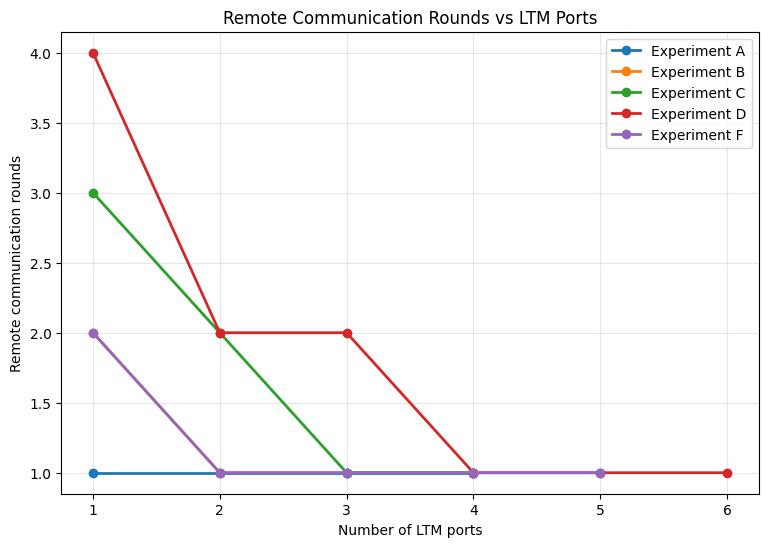

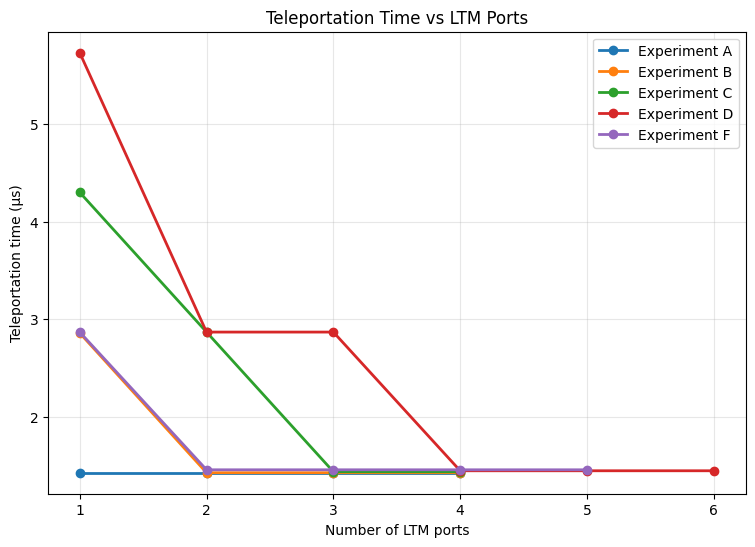

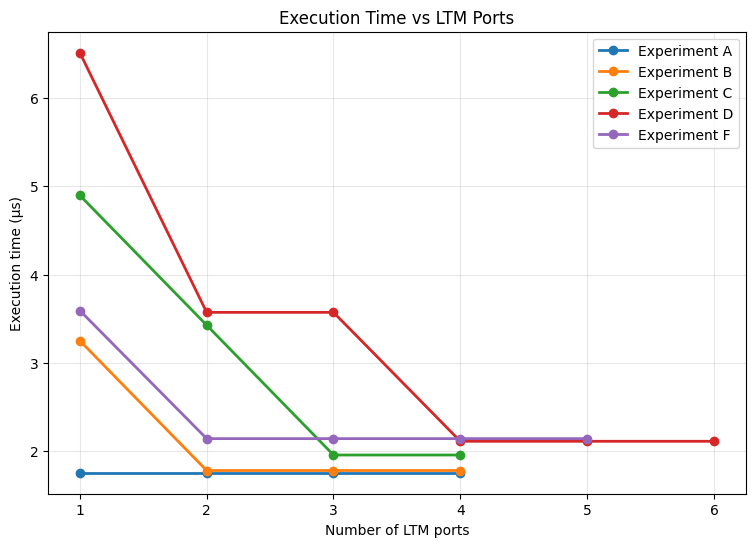

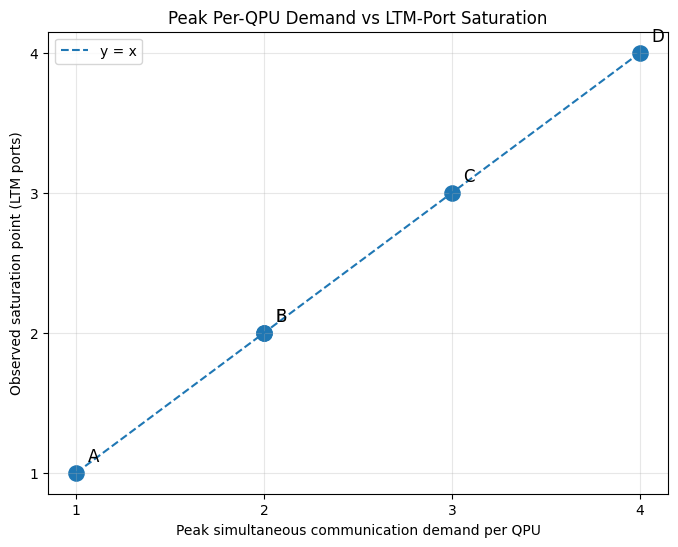

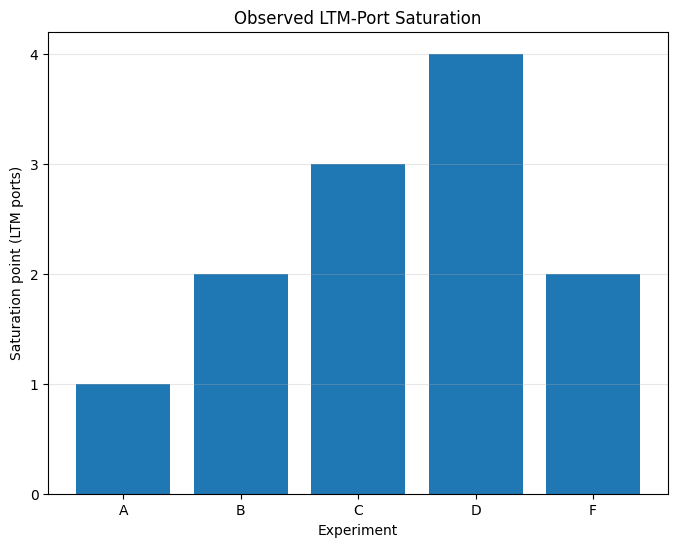

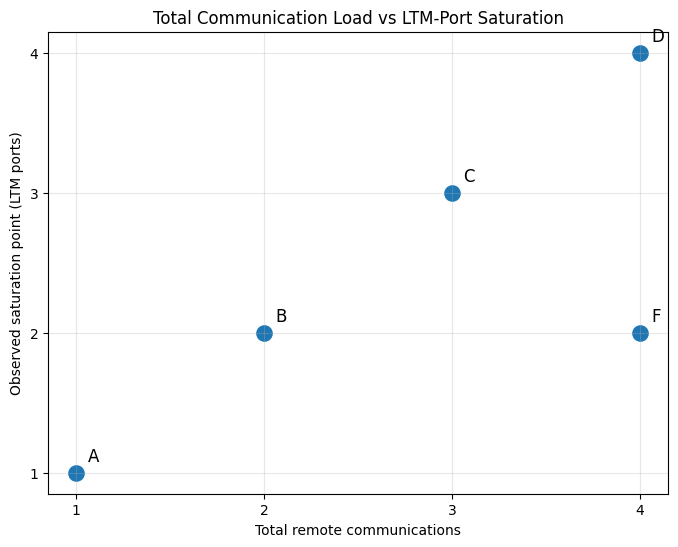


All plots saved in:
/content/LTM_plots

Files:
/content/LTM_plots/plot1_remote_rounds.png
/content/LTM_plots/plot2_teleportation_time.png
/content/LTM_plots/plot3_execution_time.png
/content/LTM_plots/plot4_peak_demand_vs_saturation.png
/content/LTM_plots/plot5_saturation_by_experiment.png
/content/LTM_plots/plot6_total_load_vs_saturation.png


In [172]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# RESULTS
# ============================================================

data = [
    # A
    ["A",1,1,1,1.43001,1.75576],
    ["A",2,1,1,1.43001,1.75576],
    ["A",3,1,1,1.43001,1.75576],
    ["A",4,1,1,1.43001,1.75576],

    # B
    ["B",1,2,1,2.86002,3.25089],
    ["B",2,1,2,1.43001,1.78089],
    ["B",3,1,2,1.43001,1.78089],
    ["B",4,1,2,1.43001,1.78089],

    # C
    ["C",1,3,1,4.30003,4.89634],
    ["C",2,2,2,2.87002,3.42633],
    ["C",3,1,3,1.44001,1.95632],
    ["C",4,1,3,1.44001,1.95632],

    # D
    ["D",1,4,1,5.73004,6.51179],
    ["D",2,2,2,2.87002,3.57177],
    ["D",3,2,3,2.87002,3.57177],
    ["D",4,1,4,1.45001,2.11176],
    ["D",5,1,4,1.45001,2.11176],
    ["D",6,1,4,1.45001,2.11176],

    # F
    ["F",1,2,1,2.87002,3.59177],
    ["F",2,1,2,1.46001,2.14176],
    ["F",3,1,2,1.46001,2.14176],
    ["F",4,1,2,1.46001,2.14176],
    ["F",5,1,2,1.46001,2.14176],
]

df = pd.DataFrame(data, columns=[
    "Experiment",
    "LTM_Ports",
    "Remote_Rounds",
    "Peak_Per_QPU_Demand",
    "Teleportation_Time_us",
    "Execution_Time_us"
])

# Output folder
out = Path("/content/LTM_plots")
out.mkdir(exist_ok=True)

# ============================================================
# PLOT 1
# Remote communication rounds vs ports
# ============================================================

plt.figure(figsize=(9,6))

for exp in ["A","B","C","D","F"]:
    x = df[df.Experiment == exp]

    plt.plot(
        x.LTM_Ports,
        x.Remote_Rounds,
        marker="o",
        linewidth=2,
        label=f"Experiment {exp}"
    )

plt.xlabel("Number of LTM ports")
plt.ylabel("Remote communication rounds")
plt.title("Remote Communication Rounds vs LTM Ports")
plt.xticks(range(1,7))
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(out/"plot1_remote_rounds.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# PLOT 2
# Teleportation time vs ports
# ============================================================

plt.figure(figsize=(9,6))

for exp in ["A","B","C","D","F"]:
    x = df[df.Experiment == exp]

    plt.plot(
        x.LTM_Ports,
        x.Teleportation_Time_us,
        marker="o",
        linewidth=2,
        label=f"Experiment {exp}"
    )

plt.xlabel("Number of LTM ports")
plt.ylabel("Teleportation time (µs)")
plt.title("Teleportation Time vs LTM Ports")
plt.xticks(range(1,7))
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(out/"plot2_teleportation_time.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# PLOT 3
# Execution time vs ports
# ============================================================

plt.figure(figsize=(9,6))

for exp in ["A","B","C","D","F"]:
    x = df[df.Experiment == exp]

    plt.plot(
        x.LTM_Ports,
        x.Execution_Time_us,
        marker="o",
        linewidth=2,
        label=f"Experiment {exp}"
    )

plt.xlabel("Number of LTM ports")
plt.ylabel("Execution time (µs)")
plt.title("Execution Time vs LTM Ports")
plt.xticks(range(1,7))
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(out/"plot3_execution_time.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# PLOT 4
# Peak demand vs saturation
# ============================================================

summary = pd.DataFrame({
    "Experiment": ["A","B","C","D","F"],
    "Peak_Demand": [1,2,3,4,2],
    "Saturation": [1,2,3,4,2]
})

plt.figure(figsize=(8,6))

plt.scatter(
    summary.Peak_Demand,
    summary.Saturation,
    s=120
)

for _, row in summary.iterrows():
    plt.annotate(
        row.Experiment,
        (row.Peak_Demand, row.Saturation),
        xytext=(8,8),
        textcoords="offset points",
        fontsize=12
    )

plt.plot(
    [1,2,3,4],
    [1,2,3,4],
    "--",
    linewidth=1.5,
    label="y = x"
)

plt.xlabel("Peak simultaneous communication demand per QPU")
plt.ylabel("Observed saturation point (LTM ports)")
plt.title("Peak Per-QPU Demand vs LTM-Port Saturation")
plt.xticks(range(1,5))
plt.yticks(range(1,5))
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(out/"plot4_peak_demand_vs_saturation.png",
            dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# PLOT 5
# Saturation point by experiment
# ============================================================

plt.figure(figsize=(8,6))

plt.bar(
    summary.Experiment,
    summary.Saturation
)

plt.xlabel("Experiment")
plt.ylabel("Saturation point (LTM ports)")
plt.title("Observed LTM-Port Saturation")
plt.yticks(range(0,5))
plt.grid(axis="y", alpha=0.3)

plt.savefig(out/"plot5_saturation_by_experiment.png",
            dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# PLOT 6
# Total communication vs saturation
# ============================================================

total = {
    "A":1,
    "B":2,
    "C":3,
    "D":4,
    "F":4
}

summary["Total_Communications"] = summary.Experiment.map(total)

plt.figure(figsize=(8,6))

plt.scatter(
    summary.Total_Communications,
    summary.Saturation,
    s=120
)

for _, row in summary.iterrows():
    plt.annotate(
        row.Experiment,
        (row.Total_Communications, row.Saturation),
        xytext=(8,8),
        textcoords="offset points",
        fontsize=12
    )

plt.xlabel("Total remote communications")
plt.ylabel("Observed saturation point (LTM ports)")
plt.title("Total Communication Load vs LTM-Port Saturation")
plt.xticks(range(1,5))
plt.yticks(range(1,5))
plt.grid(True, alpha=0.3)

plt.savefig(out/"plot6_total_load_vs_saturation.png",
            dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# SHOW SAVED FILES
# ============================================================

print("\nAll plots saved in:")
print(out)

print("\nFiles:")
for f in sorted(out.iterdir()):
    print(f)

Communication cost

In [173]:
%cd /content/qcomm

!cp samples/test_circuit samples/test_circuit_backup

/content/qcomm


In [174]:
from pathlib import Path

qcomm_dir = Path("/content/qcomm")
circuit_dir = qcomm_dir / "load_experiments"
circuit_dir.mkdir(exist_ok=True)

# One single-qubit gate per qubit
single_gates = " ".join(f"G1({q})" for q in range(16))

# Remote 2-qubit gates.
# We progressively increase the communication load.
loads = {
    1: [
        (1, 0)
    ],

    2: [
        (1, 0),
        (2, 4)
    ],

    3: [
        (1, 0),
        (2, 4),
        (3, 8)
    ],

    4: [
        (1, 0),
        (2, 4),
        (3, 8),
        (5, 12)
    ],

    5: [
        (1, 0),
        (2, 4),
        (3, 8),
        (5, 12),
        (6, 16)
    ]
}

for load, remote_gates in loads.items():

    remote = " ".join(
        f"G2({q1} {q2})"
        for q1, q2 in remote_gates
    )

    circuit_text = single_gates + "\n" + remote + "\n"

    filename = circuit_dir / f"load_{load}.circuit"
    filename.write_text(circuit_text)

    print(f"Created load {load}: {filename}")

Created load 1: /content/qcomm/load_experiments/load_1.circuit
Created load 2: /content/qcomm/load_experiments/load_2.circuit
Created load 3: /content/qcomm/load_experiments/load_3.circuit
Created load 4: /content/qcomm/load_experiments/load_4.circuit
Created load 5: /content/qcomm/load_experiments/load_5.circuit


In [175]:
architecture = """mesh_x: 2
mesh_y: 2
link_width: 8
qubits_per_core: 10
ltm_ports: 3
radio_channels: 1
wireless_enabled: false
wireless_mac: 0
teleportation_type: 0
dst_selection_mode: 0
mapping_type: 1
"""

arch_file = qcomm_dir / "load_experiment_architecture.yaml"
arch_file.write_text(architecture)

print(arch_file.read_text())

mesh_x: 2
mesh_y: 2
link_width: 8
qubits_per_core: 10
ltm_ports: 3
radio_channels: 1
wireless_enabled: false
wireless_mac: 0
teleportation_type: 0
dst_selection_mode: 0
mapping_type: 1



In [176]:
%cd /content/qcomm

import subprocess
import re
from pathlib import Path

results = []

for load in sorted(loads):

    circuit = f"load_experiments/load_{load}.circuit"

    print("\n" + "="*60)
    print(f"COMMUNICATION LOAD = {load}")
    print("="*60)

    result = subprocess.run(
        [
            "./qcomm",
            "-c", circuit,
            "-a", "load_experiment_architecture.yaml",
            "-p", "samples/parameters.yaml"
        ],
        capture_output=True,
        text=True
    )

    output = result.stdout + "\n" + result.stderr

    print(output)

    # Extract useful measurements where available
    rounds = len(re.findall(r"REMOTE ROUND:", output))

    tele_match = re.search(
        r"Teleportation time:\s*([0-9.eE+-]+)",
        output
    )

    exec_match = re.search(
        r"Execution time:\s*([0-9.eE+-]+)",
        output
    )

    teleportation_time = (
        float(tele_match.group(1))
        if tele_match else None
    )

    execution_time = (
        float(exec_match.group(1))
        if exec_match else None
    )

    results.append({
        "Load": load,
        "LTM_ports": 3,
        "Remote_rounds": rounds,
        "Teleportation_time_us": teleportation_time,
        "Execution_time_us": execution_time,
        "Return_code": result.returncode
    })

/content/qcomm

COMMUNICATION LOAD = 1

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c load_experiments/load_1.circuit -a load_experiment_architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 17
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 94.1176 # %
    '2-input': 5.88235 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    

In [177]:
import pandas as pd

df = pd.DataFrame(results)

display(df)

,Load,LTM_ports,Remote_rounds,Teleportation_time_us,Execution_time_us,Return_code
0,1,3,1,None,None,0
1,2,3,1,None,None,0
2,3,3,1,None,None,0
3,4,3,2,None,None,0
4,5,3,1,None,None,-6


In [178]:
%cd /content/qcomm

import subprocess

for load in range(1, 6):
    print("\n" + "#"*80)
    print(f"FULL OUTPUT — LOAD {load}")
    print("#"*80)

    result = subprocess.run(
        [
            "./qcomm",
            "-c", f"load_experiments/load_{load}.circuit",
            "-a", "load_experiment_architecture.yaml",
            "-p", "samples/parameters.yaml"
        ],
        capture_output=True,
        text=True
    )

    print("RETURN CODE:", result.returncode)
    print("\n--- STDOUT ---")
    print(result.stdout)
    print("\n--- STDERR ---")
    print(result.stderr)

/content/qcomm

################################################################################
FULL OUTPUT — LOAD 1
################################################################################
RETURN CODE: 0

--- STDOUT ---

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c load_experiments/load_1.circuit -a load_experiment_architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 17
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 94.1176 # %
    '2-input': 5.88235 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 

In [179]:
from pathlib import Path

qcomm_dir = Path("/content/qcomm")

single_gates = " ".join(f"G1({q})" for q in range(16))

# 5 remote gates using only q0-q15
remote_gates = [
    (1, 0),
    (2, 4),
    (3, 8),
    (5, 12),
    (6, 0)
]

remote = " ".join(
    f"G2({q1} {q2})"
    for q1, q2 in remote_gates
)

circuit_text = single_gates + "\n" + remote + "\n"

filename = qcomm_dir / "load_experiments/load_5_16q.circuit"
filename.write_text(circuit_text)

print(filename)
print("\nCircuit:")
print(circuit_text)

/content/qcomm/load_experiments/load_5_16q.circuit

Circuit:
G1(0) G1(1) G1(2) G1(3) G1(4) G1(5) G1(6) G1(7) G1(8) G1(9) G1(10) G1(11) G1(12) G1(13) G1(14) G1(15)
G2(1 0) G2(2 4) G2(3 8) G2(5 12) G2(6 0)



In [180]:
%cd /content/qcomm

!./qcomm \
-c load_experiments/load_5_16q.circuit \
-a load_experiment_architecture.yaml \
-p samples/parameters.yaml

/content/qcomm

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c load_experiments/load_5_16q.circuit -a load_experiment_architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 21
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 76.1905 # %
    '2-input': 23.8095 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits

In [181]:
%cd /content/qcomm

!sed 's/ltm_ports: 3/ltm_ports: 1/' \
load_experiment_architecture.yaml > load_experiment_architecture_p1.yaml

!./qcomm \
-c load_experiments/load_5_16q.circuit \
-a load_experiment_architecture_p1.yaml \
-p samples/parameters.yaml

/content/qcomm

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c load_experiments/load_5_16q.circuit -a load_experiment_architecture_p1.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 21
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 76.1905 # %
    '2-input': 23.8095 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 1
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # b

In [182]:
%cd /content/qcomm

!sed 's/ltm_ports: 3/ltm_ports: 2/' \
load_experiment_architecture.yaml > load_experiment_architecture_p2.yaml

!./qcomm \
-c load_experiments/load_5_16q.circuit \
-a load_experiment_architecture_p2.yaml \
-p samples/parameters.yaml

/content/qcomm

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c load_experiments/load_5_16q.circuit -a load_experiment_architecture_p2.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 21
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 76.1905 # %
    '2-input': 23.8095 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 2
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # b

In [183]:
%cd /content/qcomm

!sed 's/ltm_ports: 3/ltm_ports: 4/' \
load_experiment_architecture.yaml > load_experiment_architecture_p4.yaml

!./qcomm \
-c load_experiments/load_5_16q.circuit \
-a load_experiment_architecture_p4.yaml \
-p samples/parameters.yaml

/content/qcomm

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c load_experiments/load_5_16q.circuit -a load_experiment_architecture_p4.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 21
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 76.1905 # %
    '2-input': 23.8095 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 4
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # b

actual communication

In [184]:
%cd /content/qcomm

!./qcomm \
-c load_experiments/load_1.circuit \
-a load_experiment_architecture.yaml \
-p samples/parameters.yaml


/content/qcomm

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c load_experiments/load_1.circuit -a load_experiment_architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 17
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 94.1176 # %
    '2-input': 5.88235 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  C

In [185]:
%cd /content/qcomm

!./qcomm \
-c load_experiments/load_2.circuit \
-a load_experiment_architecture.yaml \
-p samples/parameters.yaml

/content/qcomm

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c load_experiments/load_2.circuit -a load_experiment_architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 18
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 88.8889 # %
    '2-input': 11.1111 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  C

In [186]:
%cd /content/qcomm

!./qcomm \
-c load_experiments/load_3.circuit \
-a load_experiment_architecture.yaml \
-p samples/parameters.yaml

/content/qcomm

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c load_experiments/load_3.circuit -a load_experiment_architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 19
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 84.2105 # %
    '2-input': 15.7895 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  C

In [187]:
%cd /content/qcomm

!./qcomm \
-c load_experiments/load_4.circuit \
-a load_experiment_architecture.yaml \
-p samples/parameters.yaml

/content/qcomm

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c load_experiments/load_4.circuit -a load_experiment_architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 20
  number_of_stages: 2
  distribution_of_gates:
    '1-input': 80 # %
    '2-input': 20 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec
    link_width: 8 # bits
  Cores:
    

In [193]:
import subprocess
import re
import matplotlib.pyplot as plt

%cd /content/qcomm

# ---------------------------------------------------------
# Architecture: 3 LTM ports, larger local capacity
# ---------------------------------------------------------

with open("load10_architecture.yaml", "w") as f:
    f.write("""mesh_x: 2
mesh_y: 2
link_width: 8
qubits_per_core: 20
ltm_ports: 3
radio_channels: 1
wireless_enabled: false
wireless_mac: 0
teleportation_type: 0
dst_selection_mode: 0
mapping_type: 1
""")

# ---------------------------------------------------------
# Initial sequential mapping for 40 qubits:
#
# C0: 0,4,8,12,16,20,24,28,32,36
# C1: 1,5,9,13,17,21,25,29,33,37
# C2: 2,6,10,14,18,22,26,30,34,38
# C3: 3,7,11,15,19,23,27,31,35,39
#
# Use unique C0 qubits as destinations.
# Use unique non-C0 qubits as sources.
# ---------------------------------------------------------

destination_qubits = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36]
source_qubits      = [1, 2, 3, 5, 6, 7, 9, 10, 11, 13]

results = []

for load in range(1, 11):

    filename = f"load_experiments/heavy_load_{load}.circuit"

    gates = []

    # One-qubit gates for all 40 qubits.
    for q in range(40):
        gates.append(f"G1({q})")

    # Exactly 'load' independent remote gates.
    for i in range(load):
        gates.append(
            f"G2({source_qubits[i]} {destination_qubits[i]})"
        )

    with open(filename, "w") as f:
        f.write(" ".join(gates) + "\n")

    # Run qcomm
    cmd = [
        "./qcomm",
        "-c", filename,
        "-a", "load10_architecture.yaml",
        "-p", "samples/parameters.yaml"
    ]

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True
    )

    text = result.stdout + result.stderr

    # -----------------------------------------------------
    # Extract actual teleportations
    # -----------------------------------------------------

    tp_match = re.search(
        r"teleportations_per_qubit:\s*\{([^}]*)\}",
        text
    )

    if tp_match:
        tp_text = tp_match.group(1).strip()

        if tp_text:
            actual_teleportations = len(
                [x for x in tp_text.split(",") if x.strip()]
            )
        else:
            actual_teleportations = 0
    else:
        actual_teleportations = 0

    # Number of remote rounds
    rounds = len(re.findall(r"REMOTE ROUND:", text))

    # Execution time
    exec_match = re.search(
        r"execution_time:\s*([\d.eE+-]+)",
        text
    )

    # Teleportation time
    tp_time_match = re.search(
        r"teleportation_time:\s*([\d.eE+-]+)",
        text
    )

    if exec_match and tp_time_match:

        execution_us = float(exec_match.group(1)) * 1e6
        teleportation_us = float(tp_time_match.group(1)) * 1e6

        results.append({
            "requested_load": load,
            "actual_load": actual_teleportations,
            "rounds": rounds,
            "teleportation_us": teleportation_us,
            "execution_us": execution_us
        })

    else:
        print(f"Load {load} FAILED")

# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("HEAVY COMMUNICATION LOAD — 3 LTM PORTS")
print("=" * 75)

print(
    f"{'Requested':>10} "
    f"{'Actual':>8} "
    f"{'Rounds':>8} "
    f"{'Teleportation (µs)':>22} "
    f"{'Execution (µs)':>18}"
)

for r in results:
    print(
        f"{r['requested_load']:>10} "
        f"{r['actual_load']:>8} "
        f"{r['rounds']:>8} "
        f"{r['teleportation_us']:>22.5f} "
        f"{r['execution_us']:>18.5f}"
    )

# ---------------------------------------------------------
# Verify that the experiment really produced 1–10 loads
# ---------------------------------------------------------

actual = [r["actual_load"] for r in results]

print("\nActual loads obtained:", actual)

if actual == list(range(1, 11)):
    print("✓ VALID: simulator produced exactly 1–10 teleportations.")
else:
    print("⚠ WARNING: actual loads do not match 1–10.")
    print("Do NOT use the graph for the paper yet.")

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

if actual == list(range(1, 11)):

    x = [r["actual_load"] for r in results]
    y = [r["execution_us"] for r in results]

    plt.figure(figsize=(9, 5))
    plt.plot(x, y, marker="o")

    plt.xlabel("Number of Remote Communications")
    plt.ylabel("Execution Time (µs)")
    plt.title("Execution Delay vs Heavy Communication Load (3 LTM Ports)")
    plt.xticks(x)
    plt.grid(True)

    plt.show()

/content/qcomm
Load 10 FAILED

HEAVY COMMUNICATION LOAD — 3 LTM PORTS
 Requested   Actual   Rounds     Teleportation (µs)     Execution (µs)
         1        1        1                1.43001            2.35109
         2        2        1                1.43001            2.37873
         3        3        1                1.44001            2.41637
         4        4        2                2.87002            3.91402
         5        5        2                2.87002            3.94166
         6        6        2                2.88002            3.97930
         7        7        3                4.31003            5.47695
         8        8        3                4.31003            5.50459
         9        9        3                4.32003            5.54223

Actual loads obtained: [1, 2, 3, 4, 5, 6, 7, 8, 9]
⚠ WARNING: actual loads do not match 1–10.
Do NOT use the graph for the paper yet.


In [194]:
%cd /content/qcomm

# Create a second controlled workload:
# 6 remote communications, then 7 remote communications.
# Keep 3 LTM ports fixed.

pairs6 = [
    (1,0),
    (2,4),
    (3,8),
    (5,12),
    (6,0),
    (7,4)
]

pairs7 = pairs6 + [(9,8)]

for n, pairs in [(6, pairs6), (7, pairs7)]:

    filename = f"load_experiments/validation_{n}.circuit"

    gates = [f"G1({q})" for q in range(16)]

    for a, b in pairs:
        gates.append(f"G2({a} {b})")

    with open(filename, "w") as f:
        f.write(" ".join(gates) + "\n")

    print(f"\n===== VALIDATION LOAD {n} =====")

    !./qcomm -c {filename} -a load_experiment_architecture.yaml -p samples/parameters.yaml

/content/qcomm

===== VALIDATION LOAD 6 =====

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c load_experiments/validation_6.circuit -a load_experiment_architecture.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 16
  number_of_gates: 22
  number_of_stages: 1
  distribution_of_gates:
    '1-input': 72.7273 # %
    '2-input': 27.2727 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 10
  total_physical_qubits: 40
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-

In [195]:
%cd /content/qcomm

import os

os.makedirs("load_experiments", exist_ok=True)

# ---------------------------------------------------------
# Fixed architecture: 3 LTM ports
# ---------------------------------------------------------

architecture = """mesh_x: 2
mesh_y: 2
link_width: 8
qubits_per_core: 20
ltm_ports: 3
radio_channels: 1
wireless_enabled: false
wireless_mac: 0
teleportation_type: 0
dst_selection_mode: 0
mapping_type: 1
"""

with open("load_experiments/three_port_arch.yaml", "w") as f:
    f.write(architecture)

# ---------------------------------------------------------
# 40 qubits
#
# Initial mapping:
# C0: 0,4,8,12,16,20,24,28,32,36
# C1: 1,5,9,13,17,21,25,29,33,37
# C2: 2,6,10,14,18,22,26,30,34,38
# C3: 3,7,11,15,19,23,27,31,35,39
#
# Every G2 below has destination in C0.
# ---------------------------------------------------------

destination = [0, 4, 8, 12, 16, 20, 24, 28, 32]
source =      [1, 2, 3, 5, 6, 7, 9, 10, 11]

pairs = list(zip(source, destination))

results = []

for load in range(4, 10):

    filename = f"load_experiments/load_{load}.circuit"

    gates = [f"G1({q})" for q in range(40)]

    # Add exactly 'load' remote communications
    for src, dst in pairs[:load]:
        gates.append(f"G2({src} {dst})")

    with open(filename, "w") as f:
        f.write(" ".join(gates) + "\n")

    print("\n" + "="*70)
    print(f"                 LOAD {load}")
    print("="*70)

    # Run qcomm
    !./qcomm -c {filename} -a load_experiments/three_port_arch.yaml -p samples/parameters.yaml

/content/qcomm

                 LOAD 4

#   __ _  ___ ___  _ __ ___  _ __ ___  
#  / _` |/ __/ _ \| '_ ` _ \| '_ ` _ \ 
# | (_| | (_| (_) | | | | | | | | | | |
#  \__, |\___\___/|_| |_| |_|_| |_| |_|
#    |_|                              
#        
#        qcomm - Quantum Communication Simulator
#        Author: Maurizio Palesi (University of Catania)
#        Email: maurizio.palesi@unict.it
#        GitHub: https://github.com/mpalesi/qcomm

command_line: './qcomm -c load_experiments/load_4.circuit -a load_experiments/three_port_arch.yaml -p samples/parameters.yaml'

Circuit:
  number_of_qubits: 40
  number_of_gates: 44
  number_of_stages: 1
  distribution_of_gates:
    '1-input': 90.9091 # %
    '2-input': 9.09091 # %

Architecture:
  number_of_cores: 4
  qubits_per_core: 20
  total_physical_qubits: 80
  ltm_ports: 3
  teleportation_type: 0 # all to all
  dst_selection_mode: 0 # load independent
  mapping_type: 1 # sequential
  NoC:
    mesh_size: '2x2'
    clock_period: 1e-08 # sec